<a href="https://colab.research.google.com/github/mjjaiavinash/avinash-codebooster-2026/blob/main/Day%204/Day4_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month, to_date, col, round as spark_round
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/drive/MyDrive/15 days intern dataset/large_sales_data.csv')

In [12]:
# =====================================================
# DAY 4 - BIG DATA SALES ANALYSIS USING PYSPARK
# =====================================================

# Import Required Libraries
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col,
    to_date,
    year,
    month
)

# =====================================================
# STEP 1: CREATE SPARK SESSION
# =====================================================

spark = SparkSession.builder \
    .appName("Day4_BigData_Sales") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

print("Spark Version:", spark.version)
print("SparkSession:", "ACTIVE")
print("Application:", spark.sparkContext.appName)

# =====================================================
# STEP 2: LOAD DATASET (BRONZE LAYER)
# =====================================================

df_bronze = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/content/drive/MyDrive/15 days intern dataset/large_sales_data.csv")

print("\n===== Bronze Layer Loaded =====")
print("Rows:", df_bronze.count())
print("Columns:", len(df_bronze.columns))

# =====================================================
# STEP 3: CREATE TOTAL PRICE COLUMN
# =====================================================

df_bronze = df_bronze.withColumn(
    "total_price",
    col("unit_price") + col("revenue")
)

print("\n===== Unit Price + Revenue =====")

df_bronze.select(
    "unit_price",
    "revenue",
    "total_price"
).show(5, truncate=False)

# =====================================================
# STEP 4: CREATE SILVER LAYER
# Data Cleaning & Transformation
# =====================================================

df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=["quantity", "unit_price", "revenue"])

# Convert date and extract year/month

df_silver = df_silver \
    .withColumn(
        "order_date",
        to_date(col("order_date"), "yyyy-MM-dd")
    ) \
    .withColumn(
        "year",
        year(col("order_date"))
    ) \
    .withColumn(
        "month",
        month(col("order_date"))
    )

# Revenue Categorization

df_silver = df_silver.withColumn(
    "revenue_category",
    F.when(col("revenue") > 40000, "High")
     .when(
         (col("revenue") > 10000) &
         (col("revenue") <= 40000),
         "Medium"
     )
     .otherwise("Low")
)

print("\n===== Silver Layer Sample =====")
df_silver.show(5)

print(f"Silver Table Row Count : {df_silver.count()}")
print(f"Silver Table Column Count : {len(df_silver.columns)}")

# =====================================================
# STEP 5: SAVE SILVER LAYER AS PARQUET
# =====================================================

df_silver.write \
    .mode("overwrite") \
    .parquet("sales_silver.parquet")

print("\nSilver Parquet Saved Successfully")

# =====================================================
# STEP 6: TOP 5 PRODUCTS BY REVENUE
# =====================================================

top_products = (
    df_silver
    .groupBy("product")
    .agg(
        F.sum("revenue").alias("total_revenue"),
        F.count("order_id").alias("num_orders"),
        F.avg("revenue").alias("avg_order_revenue")
    )
    .orderBy(F.desc("total_revenue"))
    .limit(5)
)

print("\n===== Top 5 Products By Revenue =====")

top_products.show(truncate=False)

# =====================================================
# STEP 7: REVENUE BY REGION
# =====================================================

revenue_by_region = (
    df_silver
    .groupBy("region")
    .agg(
        F.sum("revenue").alias("total_revenue"),
        F.count("order_id").alias("total_orders"),
        F.countDistinct("customer_name")
        .alias("unique_customers")
    )
    .orderBy(F.desc("total_revenue"))
)

print("\n===== Revenue By Region =====")

revenue_by_region.show(truncate=False)

# =====================================================
# STEP 8: MONTHLY REVENUE TREND
# =====================================================

from pyspark.sql.functions import date_format

monthly_revenue_trend = (
    df_silver
    .withColumn("month_num", month("order_date"))
    .withColumn("order_month", date_format("order_date", "MMMM"))
    .groupBy("month_num", "order_month")
    .agg(
        F.sum("revenue").alias("monthly_revenue"),
        F.count("order_id").alias("monthly_orders")
    )
    .orderBy("month_num")
    .drop("month_num")
)

print("\n===== Monthly Revenue Trend =====")

monthly_revenue_trend.show(truncate=False)

# =====================================================
# END OF PROJECT
# =====================================================

Spark Version: 4.0.2
SparkSession: ACTIVE
Application: Day4_BigData_Sales

===== Bronze Layer Loaded =====
Rows: 5000
Columns: 13

===== Unit Price + Revenue =====
+----------+-------+-----------+
|unit_price|revenue|total_price|
+----------+-------+-----------+
|22000     |264000 |286000     |
|12000     |120000 |132000     |
|800       |8000   |8800       |
|32000     |160000 |192000     |
|3500      |14000  |17500      |
+----------+-------+-----------+
only showing top 5 rows

===== Silver Layer Sample =====
+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+-----------+----+-----+----------------+
|order_id|customer_name|product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|total_price|year|month|revenue_category|
+--------+-------------+-------+-----------+--------+----------+-------+----------+---------+------+-----------+----

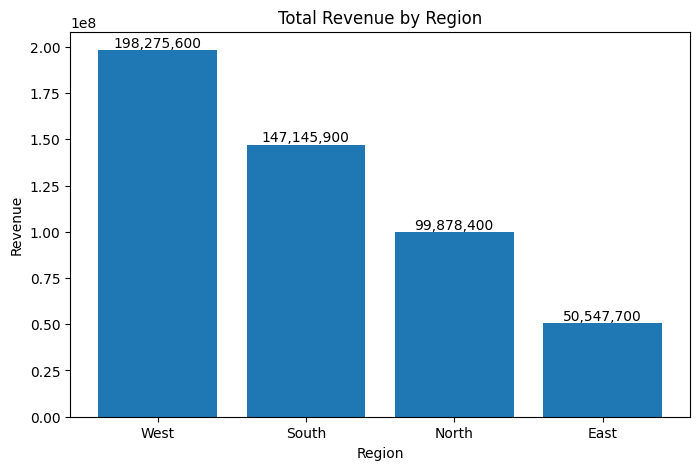

In [9]:
region_pd = revenue_by_region.toPandas()

plt.figure(figsize=(8,5))

bars = plt.bar(
    region_pd['region'],
    region_pd['total_revenue']
)

# Add revenue labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')

plt.show()

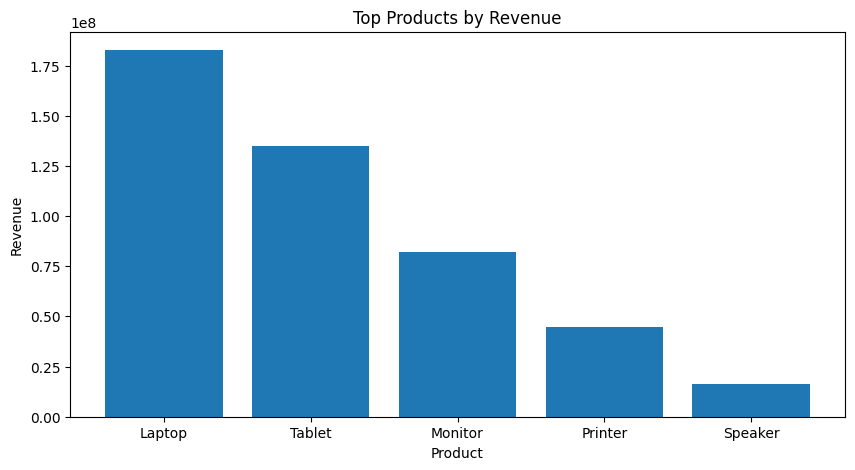

In [16]:
top_products_pd = top_products.toPandas()

plt.figure(figsize=(10,5))
plt.bar(
    top_products_pd['product'],
    top_products_pd['total_revenue']
)
plt.title('Top Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

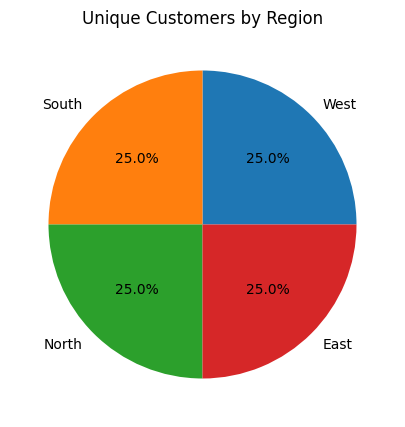

In [17]:
plt.figure(figsize=(8,5))
plt.pie(
    region_pd['unique_customers'],
    labels=region_pd['region'],
    autopct='%1.1f%%'
)
plt.title('Unique Customers by Region')
plt.show()

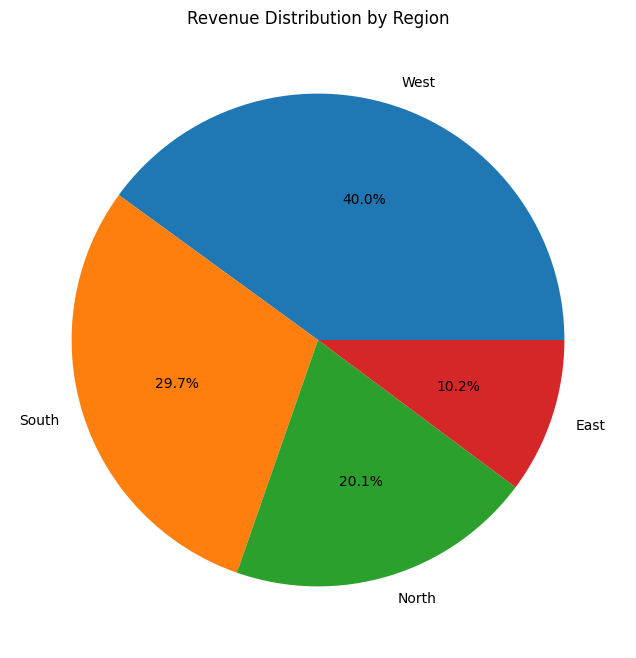

In [19]:
region_pd = revenue_by_region.toPandas()

plt.figure(figsize=(8,8))

plt.pie(
    region_pd['total_revenue'],
    labels=region_pd['region'],
    autopct='%1.1f%%'
)

plt.title('Revenue Distribution by Region')

plt.show()